In [493]:
using Pkg
Pkg.activate("ad_env")
using DataFrames
using CairoMakie
using Statistics

  Activating project at `c:\Users\Jakub\Dokumenty\Projects\ADwUB_lipidy\ad_env`


In [494]:
kalibracja = DataFrame([[0.259, 0.23, 0.214, 0.28, 0.468, 0.424, 0.219], [0.438, 1.136, 0.455, 0.373, 0.946, 0.561, 0.61], [0.39,0.228,0.439,0.444,0.208,0.278,0.466],[0.226,0.382,0.218,0.266,0.32,0.334,0.385]], [:g1_s1, :g1_s2, :g2_s1, :g2_s2])

Row,g1_s1,g1_s2,g2_s1,g2_s2
,Float64,Float64,Float64,Float64
1,0.259,0.438,0.39,0.226
2,0.23,1.136,0.228,0.382
3,0.214,0.455,0.439,0.218
4,0.28,0.373,0.444,0.266
5,0.468,0.946,0.208,0.32
6,0.424,0.561,0.278,0.334
7,0.219,0.61,0.466,0.385


In [495]:
kalibracja[!, :g1_średnia_wiersze] = mean(Matrix(kalibracja[!,[:g1_s1,:g1_s2]]), dims=2)[:,1]
kalibracja[!, :g2_średnia_wiersze] = mean(Matrix(kalibracja[!, [:g2_s1, :g2_s2]]), dims=2)[:, 1]
kalibracja[!, :g1g2_średnia_wiersze] = mean(Matrix(kalibracja[!, [:g2_s1, :g2_s2, :g1_s1, :g1_s2]]), dims=2)[:, 1]
for c in names(kalibracja)
    kalibracja[!, c] .-= kalibracja[1, c]
end
kalibracja[!,:próbka] = [0,1,2,4,6,8,10]
kalibracja

Row,g1_s1,g1_s2,g2_s1,g2_s2,g1_średnia_wiersze,g2_średnia_wiersze,g1g2_średnia_wiersze,próbka
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,-0.029,0.698,-0.162,0.156,0.3345,-0.003,0.16575,1
3,-0.045,0.017,0.049,-0.008,-0.014,0.0205,0.00325,2
4,0.021,-0.065,0.054,0.04,-0.022,0.047,0.0125,4
5,0.209,0.508,-0.182,0.094,0.3585,-0.044,0.15725,6
6,0.165,0.123,-0.112,0.108,0.144,-0.002,0.071,8
7,-0.04,0.172,0.076,0.159,0.066,0.1175,0.09175,10


In [496]:
function regresja_liniowa(x,y)
    x_śr = mean(x)
    y_śr = mean(y)
    a = sum((x .- x_śr).*(y .- y_śr)) / sum((x .- x_śr).^2)
    b = y_śr - a*x_śr
    r2 = sum((y_śr .- (a .* x .+ b)) .^ 2) / sum((y_śr .- y) .^ 2)
    return a,b,r2
end

regresja_liniowa (generic function with 1 method)

In [497]:
function wykres(ax,x,y)
    a, b, r2 = regresja_liniowa(x,y)
    linspace=0:0.1:maximum(x)
    lines!(ax,linspace,a.*linspace.+b, linestyle=:dash, label="r²=" * string(round(r2, digits=3)),linewidth=4)
    scatter!(ax, x, y, markersize=13,alpha=0.5)
    axislegend(ax, position=:rb, framevisible=false)
end


wykres (generic function with 1 method)

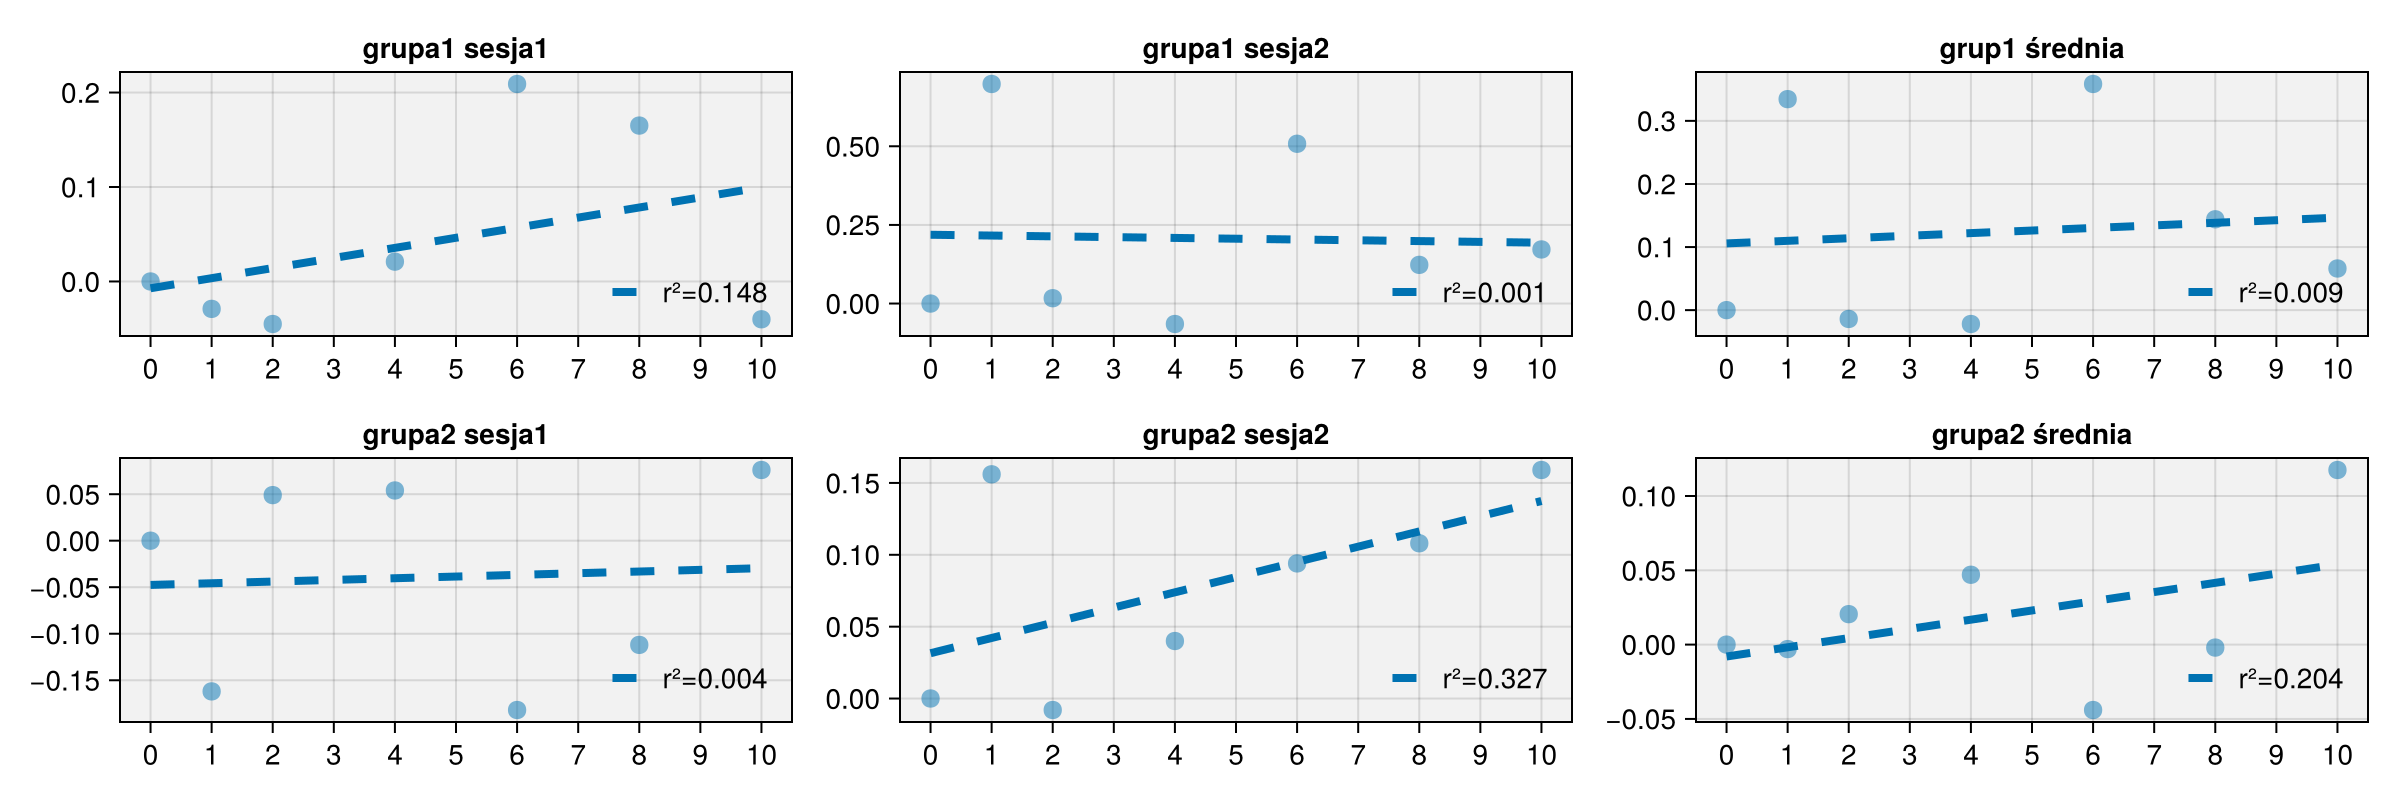

In [498]:
bkg_col = :gray95
xticks = 0:10

fig = Figure(size=(1200, 400))
ax = Axis(fig[1, 1], title="grupa1 sesja1", backgroundcolor=bkg_col, xticks=xticks)
wykres(ax, kalibracja[:, :próbka], kalibracja[:, :g1_s1])
ax = Axis(fig[1, 2], title="grupa1 sesja2", backgroundcolor=bkg_col, xticks=xticks)
wykres(ax, kalibracja[:, :próbka], kalibracja[:, :g1_s2])
ax = Axis(fig[2, 1], title="grupa2 sesja1", backgroundcolor=bkg_col, xticks=xticks)
wykres(ax, kalibracja[:, :próbka], kalibracja[:, :g2_s1])
ax = Axis(fig[2, 2], title="grupa2 sesja2", backgroundcolor=bkg_col, xticks=xticks)
wykres(ax, kalibracja[:, :próbka], kalibracja[:, :g2_s2])
ax = Axis(fig[1, 3], title="grup1 średnia", backgroundcolor=bkg_col, xticks=xticks)
wykres(ax, kalibracja[:, :próbka], kalibracja[:, :g1_średnia_wiersze])
ax = Axis(fig[2, 3], title="grupa2 średnia", backgroundcolor=bkg_col, xticks=xticks)
wykres(ax, kalibracja[:, :próbka], kalibracja[:, :g2_średnia_wiersze])
fig

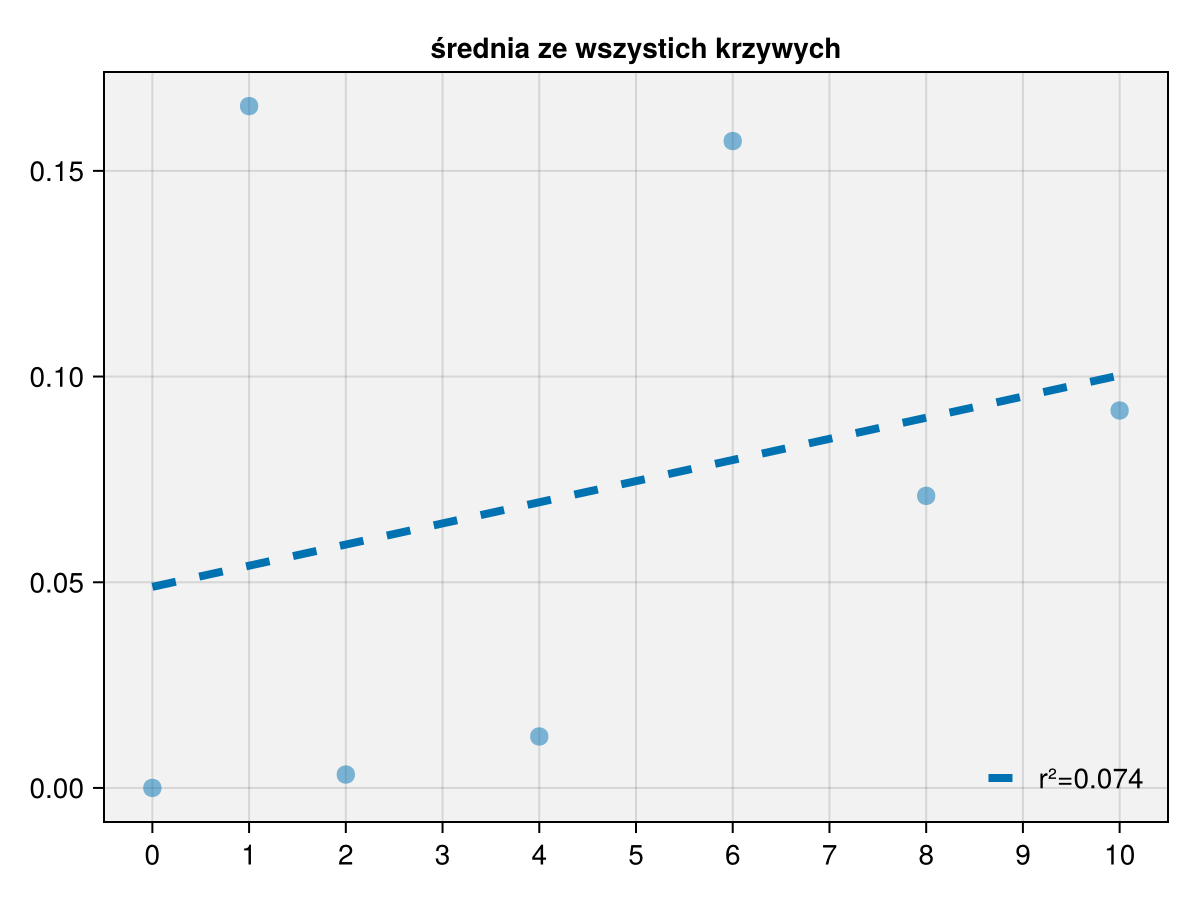

In [499]:
fig = Figure()
ax = Axis(fig[1, 1], title="średnia ze wszystich krzywych", backgroundcolor=bkg_col,xticks=xticks)
wykres(ax, kalibracja[:, :próbka], kalibracja[:, :g1g2_średnia_wiersze])
fig